# Processing Status Dashboard

Shows which tiles have been processed by reading:
- `tile_list.geojson` — all tiles with a `land` boolean column (static, created by notebook 01)
- Icechunk commit history — the single source of truth for processed tiles

Use `config/config_v1.txt` (reads credentials from env vars) or
`config/config_with_secrets_v1.txt` (literal credentials, gitignored) in the first cell.

In [1]:
import sys
from pathlib import Path

import icechunk
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from icechunk_github_actions_demo import Config, get_processing_status_gdf

# Use config_with_secrets_v1.txt for local runs; config_v1.txt reads credentials from env vars.
config = Config("config/config_with_secrets_v1.txt")

## Load tile list and check Icechunk history

In [2]:
storage = icechunk.azure_storage(
    account=config.AZURE_STORAGE_ACCOUNT,
    container=config.AZURE_CONTAINER,
    prefix=config.ICECHUNK_PREFIX,
    sas_token=config.AZURE_STORAGE_SAS_TOKEN,
)
repo = icechunk.Repository.open(storage)

In [3]:
status_gdf = get_processing_status_gdf(repo, config.TILE_LIST_PATH, config.YEARS)
status_gdf

ERROR 1: PROJ: proj_create_from_database: Open of /home/eric/repos/icechunk_github_actions_zarr_synergy/icechunk_github_actions_demo/.pixi/envs/default/share/proj failed


,row,col,land,geometry,status,2020_valid_pixels,2021_valid_pixels,2022_valid_pixels
0,0,0,False,"POLYGON ((-180 90, -180 80, -170 80, -170 90, ...",ocean,NaN,NaN,NaN
1,0,1,False,"POLYGON ((-170 90, -170 80, -160 80, -160 90, ...",ocean,NaN,NaN,NaN
2,0,2,False,"POLYGON ((-160 90, -160 80, -150 80, -150 90, ...",ocean,NaN,NaN,NaN
3,0,3,False,"POLYGON ((-150 90, -150 80, -140 80, -140 90, ...",ocean,NaN,NaN,NaN
4,0,4,False,"POLYGON ((-140 90, -140 80, -130 80, -130 90, ...",ocean,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
643,17,31,True,"POLYGON ((130 -80, 130 -90, 140 -90, 140 -80, ...",processed,574998.0,574998.0,574998.0
644,17,32,True,"POLYGON ((140 -80, 140 -90, 150 -90, 150 -80, ...",processed,604389.0,604389.0,604389.0
645,17,33,True,"POLYGON ((150 -80, 150 -90, 160 -90, 160 -80, ...",processed,377137.0,377137.0,377137.0
646,17,34,True,"POLYGON ((160 -80, 160 -90, 170 -90, 170 -80, ...",processed,67576.0,67576.0,67576.0


In [4]:
counts = status_gdf["status"].value_counts()
land_count = int((status_gdf["status"] != "ocean").sum())
processed_count = int(counts.get("processed", 0))
nodata_count = int(counts.get("nodata", 0))
unprocessed_count = int(counts.get("unprocessed", 0))

print(f"Land tiles:   {land_count}")
print(f"Processed:    {processed_count}")
print(f"No-data:      {nodata_count}")
print(f"Unprocessed:  {unprocessed_count}")
print(f"Progress:     {100 * (processed_count + nodata_count) / land_count:.1f}%")

Land tiles:   381
Processed:    218
No-data:      5
Unprocessed:  158
Progress:     58.5%


## Visualize tile status

/tmp/ipykernel_698155/2359367451.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_698155/2359367451.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_698155/2359367451.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_698155/235936

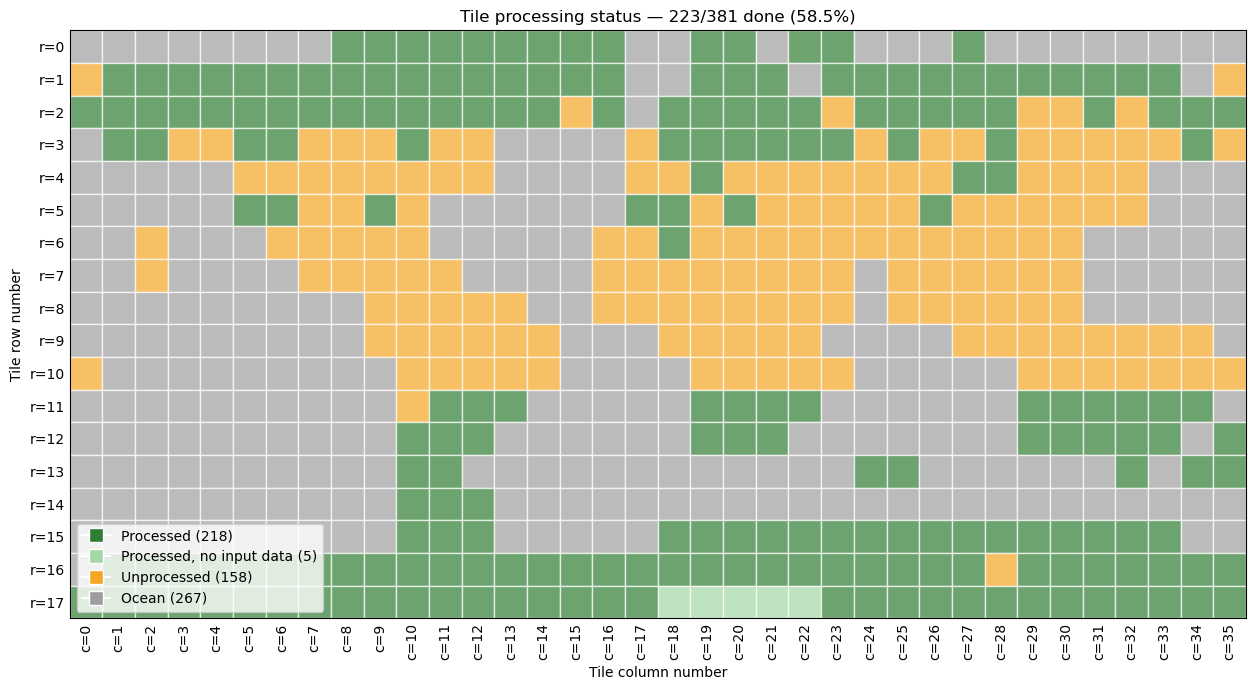

In [5]:
color_map = {
    "processed": "#2e7d32",
    "nodata": "#a5d6a7",
    "unprocessed": "#f5a623",
    "ocean": "#9e9e9e",
}

f, ax = plt.subplots(figsize=(14, 7))
status_gdf.plot(
    ax=ax,
    color=status_gdf["status"].map(color_map),
    edgecolor="white",
    alpha=0.7,
)

# ax.set_xlim(-180, 180)
# ax.set_ylim(-90, 90)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(status_gdf["col"].unique())
row_values = sorted(status_gdf["row"].unique(), reverse=True)
col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [status_gdf[status_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(status_gdf.total_bounds[0], status_gdf.total_bounds[2])
ax.set_ylim(status_gdf.total_bounds[1], status_gdf.total_bounds[3])

ax.set_title(
    f"Tile processing status — {processed_count + nodata_count}/{land_count} done "
    f"({100 * (processed_count + nodata_count) / land_count:.1f}%)"
)
handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed ({processed_count})", markerfacecolor=color_map["processed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed, no input data ({nodata_count})", markerfacecolor=color_map["nodata"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Unprocessed ({unprocessed_count})", markerfacecolor=color_map["unprocessed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Ocean ({int(counts.get('ocean', 0))})", markerfacecolor=color_map["ocean"], markersize=10),
]
ax.legend(handles=handles, loc="lower left")
f.tight_layout()

## List unprocessed tiles

In [6]:
unprocessed_gdf = status_gdf[status_gdf["status"] == "unprocessed"]
if len(unprocessed_gdf):
    print("Unprocessed tiles (row, col):")
    for _, r in unprocessed_gdf.sort_values(["row", "col"]).iterrows():
        lat_min = -90 + r["row"] * config.TILE_SIZE_DEG
        lon_min = -180 + r["col"] * config.TILE_SIZE_DEG
        print(f"  row={int(r['row'])}, col={int(r['col'])}  lat=[{lat_min:.0f}, {lat_min+10:.0f}]  lon=[{lon_min:.0f}, {lon_min+10:.0f}]")
else:
    print("All land tiles processed.")

Unprocessed tiles (row, col):
  row=1, col=0  lat=[-80, -70]  lon=[-180, -170]
  row=1, col=35  lat=[-80, -70]  lon=[170, 180]
  row=2, col=15  lat=[-70, -60]  lon=[-30, -20]
  row=2, col=23  lat=[-70, -60]  lon=[50, 60]
  row=2, col=29  lat=[-70, -60]  lon=[110, 120]
  row=2, col=30  lat=[-70, -60]  lon=[120, 130]
  row=2, col=32  lat=[-70, -60]  lon=[140, 150]
  row=3, col=3  lat=[-60, -50]  lon=[-150, -140]
  row=3, col=4  lat=[-60, -50]  lon=[-140, -130]
  row=3, col=7  lat=[-60, -50]  lon=[-110, -100]
  row=3, col=8  lat=[-60, -50]  lon=[-100, -90]
  row=3, col=9  lat=[-60, -50]  lon=[-90, -80]
  row=3, col=11  lat=[-60, -50]  lon=[-70, -60]
  row=3, col=12  lat=[-60, -50]  lon=[-60, -50]
  row=3, col=17  lat=[-60, -50]  lon=[-10, 0]
  row=3, col=24  lat=[-60, -50]  lon=[60, 70]
  row=3, col=26  lat=[-60, -50]  lon=[80, 90]
  row=3, col=27  lat=[-60, -50]  lon=[90, 100]
  row=3, col=29  lat=[-60, -50]  lon=[110, 120]
  row=3, col=30  lat=[-60, -50]  lon=[120, 130]
  row=3, col=31 

## Show spatial coverage per tile per year

/tmp/ipykernel_698155/1101512923.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_698155/1101512923.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_698155/1101512923.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_698155/110151

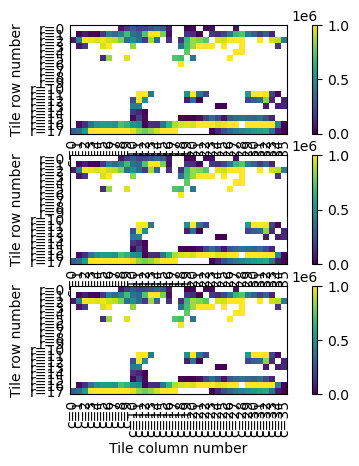

In [7]:
f, axs =plt.subplots(nrows=3)

status_gdf.plot(ax=axs[0], column="2020_valid_pixels", cmap="viridis", legend=True)
status_gdf.plot(ax=axs[1], column="2021_valid_pixels", cmap="viridis", legend=True)
status_gdf.plot(ax=axs[2], column="2022_valid_pixels", cmap="viridis", legend=True)

for ax in axs:
    ax.set_xlabel("Tile column number")
    ax.set_ylabel("Tile row number")

    col_values = sorted(status_gdf["col"].unique())
    row_values = sorted(status_gdf["row"].unique(), reverse=True)
    col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
    row_coords = [status_gdf[status_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

    ax.set_xticks(col_coords)
    ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
    ax.set_yticks(row_coords)
    ax.set_yticklabels([f"r={v}" for v in row_values])
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_xlim(status_gdf.total_bounds[0], status_gdf.total_bounds[2])
    ax.set_ylim(status_gdf.total_bounds[1], status_gdf.total_bounds[3])

## Data volumes

In [ ]:
# input data

In [ ]:
# output data volume
import adlfs

fs = adlfs.AzureBlobFileSystem(
    account_name=config.AZURE_STORAGE_ACCOUNT,
    sas_token=config.AZURE_STORAGE_SAS_TOKEN,
)

files = fs.find(f"{config.AZURE_CONTAINER}/{config.ICECHUNK_PREFIX}", detail=True)
total_bytes = sum(f["size"] for f in files.values())
print(f"Total stored: {total_bytes / 1e9:.2f} GB ({len(files):,} objects)")

Total stored: 1.49 GB (5,171 objects)
